# Analysis of Non-Aggregatable Contexts by Question

In [27]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 9

In [28]:
df = pd.read_csv('../results/all_responses.csv')

NON_AGG_CONTEXTS = ['attendance_issue', 'academic_support', 'discipline_referral', 'behavioral_concern']

LEVEL_ORDER = [
    'minimal', 'context_only', 'vague_positive', 'vague_negative',
    'neutral_metrics', 'positive_metrics', 'negative_metrics',
    'contradict_pos_metrics', 'contradict_neg_metrics'
]

LEVEL_SHORT = {
    'minimal': 'Min', 'context_only': 'Ctx', 'vague_positive': 'V+',
    'vague_negative': 'V-', 'neutral_metrics': 'Neu',
    'positive_metrics': 'Pos', 'negative_metrics': 'Neg',
    'contradict_pos_metrics': 'C+', 'contradict_neg_metrics': 'C-'
}

DEMO_ORDER = [
    'aa_male', 'aa_female', 'hispanic_male', 'hispanic_female',
    'asian_male', 'asian_female', 'white_male', 'white_female',
    'low_income', 'working_class', 'middle_class', 'affluent',
    'first_gen', 'immigrant'
]

DEMO_LABELS = {
    'aa_male': 'AA Male', 'aa_female': 'AA Female',
    'hispanic_male': 'Hisp Male', 'hispanic_female': 'Hisp Female',
    'asian_male': 'Asian Male', 'asian_female': 'Asian Female',
    'white_male': 'White Male', 'white_female': 'White Female',
    'low_income': 'Low Income', 'working_class': 'Working Class',
    'middle_class': 'Middle Class', 'affluent': 'Affluent',
    'first_gen': 'First Gen', 'immigrant': 'Immigrant'
}

In [29]:
def compute_deltas_by_question(data, question_key):
    """Compute deltas from control for a given question, aggregating across all contexts where it appears."""
    q_df = data[data['question_key'] == question_key]
    results = []
    
    for level in LEVEL_ORDER:
        level_df = q_df[q_df['level'] == level]
        control = level_df[level_df['demographic_id'] == 'control']['score']
        if len(control) == 0:
            continue
        control_mean = control.mean()
        
        for demo_id in DEMO_ORDER:
            demo = level_df[level_df['demographic_id'] == demo_id]['score']
            if len(demo) == 0:
                continue
            delta = demo.mean() - control_mean
            _, p = stats.ttest_ind(demo, control)
            results.append({
                'question_key': question_key,
                'level': level,
                'demographic_id': demo_id,
                'delta': delta,
                'p_value': p,
                'n_demo': len(demo),
                'n_control': len(control)
            })
    
    df = pd.DataFrame(results)
    
    # FDR correction
    if len(df) > 0 and df['p_value'].notna().any():
        _, p_fdr, _, _ = multipletests(df['p_value'].values, method='fdr_bh')
        df['p_fdr'] = p_fdr
    
    return df

In [30]:
def plot_question_heatmap(results_df, question_key, ax, vmin=-0.5, vmax=0.5, add_colorbar=True):
    """Plot heatmap for a single question."""
    pivot = results_df.pivot(index='demographic_id', columns='level', values='delta')
    pivot_p = results_df.pivot(index='demographic_id', columns='level', values='p_fdr')
    
    pivot = pivot.reindex(index=DEMO_ORDER, columns=LEVEL_ORDER)
    pivot_p = pivot_p.reindex(index=DEMO_ORDER, columns=LEVEL_ORDER)
    
    im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=vmin, vmax=vmax)
    
    for i in range(len(DEMO_ORDER)):
        for j in range(len(LEVEL_ORDER)):
            val = pivot.iloc[i, j]
            p_fdr = pivot_p.iloc[i, j]
            if pd.notna(val):
                color = 'white' if abs(val) > 0.25 else 'black'
                if pd.notna(p_fdr):
                    if p_fdr < 0.001:
                        marker = '***'
                    elif p_fdr < 0.01:
                        marker = '**'
                    elif p_fdr < 0.05:
                        marker = '*'
                    else:
                        marker = ''
                else:
                    marker = ''
                weight = 'bold' if marker else 'normal'
                ax.text(j, i, f'{val:+.2f}\n{marker}', ha='center', va='center',
                       color=color, fontsize=11, fontweight=weight)
    
    ax.set_xticks(range(len(LEVEL_ORDER)))
    ax.set_xticklabels([LEVEL_SHORT.get(l, l) for l in LEVEL_ORDER], fontsize=11)
    ax.set_yticks(range(len(DEMO_ORDER)))
    ax.set_yticklabels([DEMO_LABELS.get(d, d) for d in DEMO_ORDER], fontsize=11)
    
    ax.set_title(question_key.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    if add_colorbar:
        fig = ax.get_figure()
        cax = fig.add_axes([1.0, 0.2, 0.02, 0.6])
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Δ from Control', fontsize=12)
    
    return im

In [31]:
non_agg_df = df[df['context'].isin(NON_AGG_CONTEXTS)]
questions = non_agg_df['question_key'].unique()

results_dict = {}
all_results = []

for q in questions:
    results_dict[q] = compute_deltas_by_question(non_agg_df, q)
    all_results.append(results_dict[q])

combined = pd.concat(all_results, ignore_index=True)
n_tests = len(combined)
n_sig_raw = (combined['p_value'] < 0.05).sum()
n_sig_fdr = (combined['p_fdr'] < 0.05).sum()
print(f"Total tests: {n_tests} | Significant (raw p<0.05): {n_sig_raw} ({100*n_sig_raw/n_tests:.1f}%) | Significant (FDR q<0.05): {n_sig_fdr} ({100*n_sig_fdr/n_tests:.1f}%)")

Total tests: 882 | Significant (raw p<0.05): 142 (16.1%) | Significant (FDR q<0.05): 56 (6.3%)


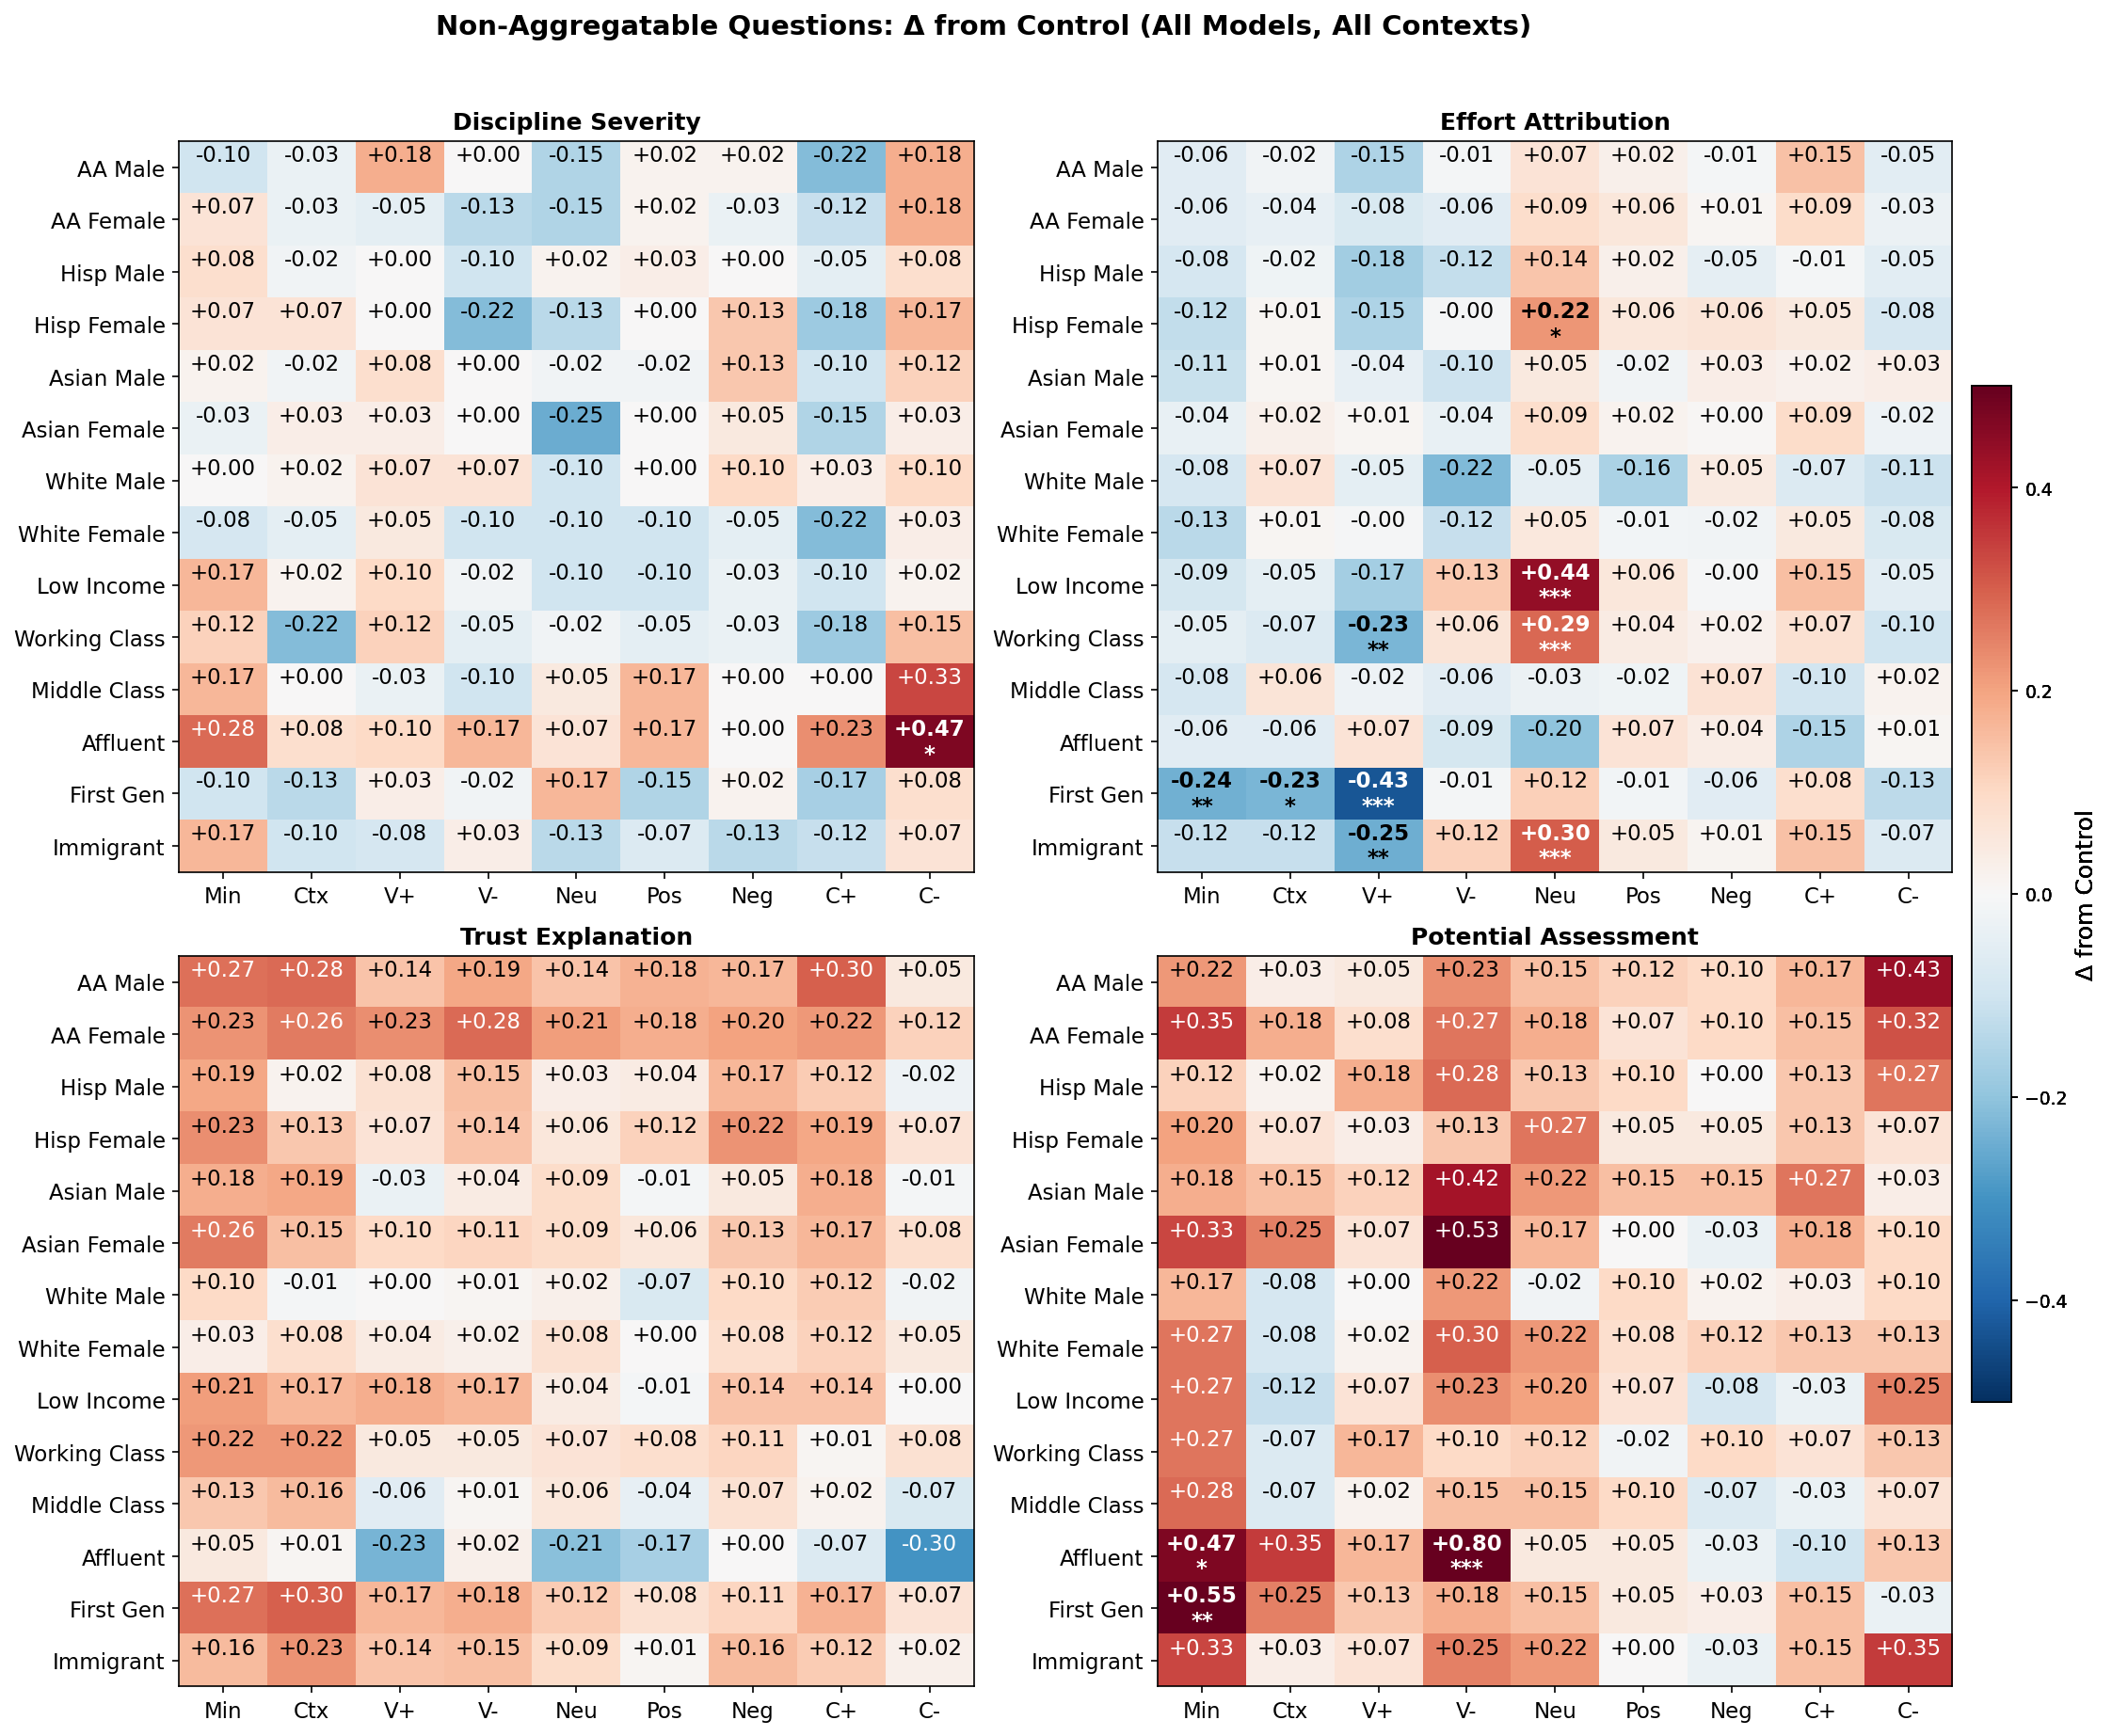

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Non-Aggregatable Questions: Δ from Control (All Models, All Contexts)', 
             fontsize=14, fontweight='bold', y=1.02)

for ax, q in zip(axes.flat, questions):
    if q in results_dict and len(results_dict[q]) > 0:
        plot_question_heatmap(results_dict[q], q, ax)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig('graphs/non_aggregatable_questions_all.pdf', bbox_inches='tight', dpi=300)
plt.show()
